In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
!unzip "/content/archive (3).zip" -d /content/datset


In [ ]:
train_dir ="/content/datset/train"
test_dir = "/content/datset/test"

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

print(train_dataset.classes)

['FAKE', 'REAL']


In [ ]:
from torch.utils.data import Subset
import numpy as np

# Get all labels
targets = np.array(train_dataset.targets)

# Get indices of each class
fake_indices = np.where(targets == 0)[0]   # FAKE
real_indices = np.where(targets == 1)[0]   # REAL

# Shuffle
np.random.shuffle(fake_indices)
np.random.shuffle(real_indices)

# Take 30k each
selected_fake = fake_indices[:30000]
selected_real = real_indices[:30000]

# Combine
selected_indices = np.concatenate([selected_fake, selected_real])

# Shuffle combined indices
np.random.shuffle(selected_indices)

train_subset = Subset(train_dataset, selected_indices)

In [ ]:
targets_test = np.array(test_dataset.targets)

fake_test = np.where(targets_test == 0)[0]
real_test = np.where(targets_test == 1)[0]

np.random.shuffle(fake_test)
np.random.shuffle(real_test)

selected_fake_test = fake_test[:3000]
selected_real_test = real_test[:3000]

selected_test_indices = np.concatenate([selected_fake_test, selected_real_test])

np.random.shuffle(selected_test_indices)

test_subset = Subset(test_dataset, selected_test_indices)

In [ ]:
from collections import Counter

labels = [train_dataset.targets[i] for i in selected_indices]
print(Counter(labels))

Counter({1: 30000, 0: 30000})


In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
model = models.efficientnet_b0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 190MB/s]


In [ ]:
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(num_features, 2)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
def train_model(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    return running_loss/len(loader), accuracy

In [ ]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total

    return accuracy, all_labels, all_preds

In [ ]:
epochs = 10

for epoch in range(epochs):

    loss, train_acc = train_model(model, train_loader)

    test_acc, _, _ = evaluate_model(model, test_loader)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy: {test_ac c:.2f}%")

100%|██████████| 1875/1875 [05:18<00:00,  5.89it/s]


Epoch 1
Loss: 0.1452
Train Accuracy: 94.34%
Test Accuracy: 97.32%


100%|██████████| 1875/1875 [05:19<00:00,  5.86it/s]


Epoch 2
Loss: 0.0733
Train Accuracy: 97.35%
Test Accuracy: 98.07%


100%|██████████| 1875/1875 [05:19<00:00,  5.87it/s]


...

Epoch 8
Loss: 0.0191
Train Accuracy: 99.34%
Test Accuracy: 98.15%


100%|██████████| 1875/1875 [05:19<00:00,  5.87it/s]


Epoch 9
Loss: 0.0154
Train Accuracy: 99.44%
Test Accuracy: 98.42%


100%|██████████| 1875/1875 [05:19<00:00,  5.87it/s]


Epoch 10
Loss: 0.0131
Train Accuracy: 99.55%
Test Accuracy: 98.15%


In [ ]:
test_acc, labels, preds = evaluate_model(model, test_loader)

print(classification_report(labels, preds, target_names=["FAKE","REAL"]))

              precision    recall  f1-score   support

        FAKE       0.99      0.97      0.98      3000
        REAL       0.97      0.99      0.98      3000

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000



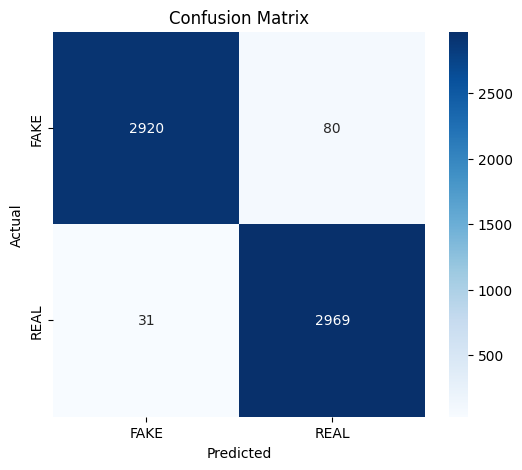

In [ ]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["FAKE","REAL"],
            yticklabels=["FAKE","REAL"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
torch.save(model.state_dict(), "efficientnet_cifake.pth")

In [ ]:
class GradCAM:

    def __init__(self, model):

        self.model = model
        self.gradients = None

        self.target_layer = model.features[-1]

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activation = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):

        output = self.model(input_image)

        self.model.zero_grad()

        loss = output[:, class_idx]

        loss.backward()

        gradients = self.gradients[0]
        activations = self.activation[0]

        weights = gradients.mean(dim=(1,2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.cpu().detach().numpy()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


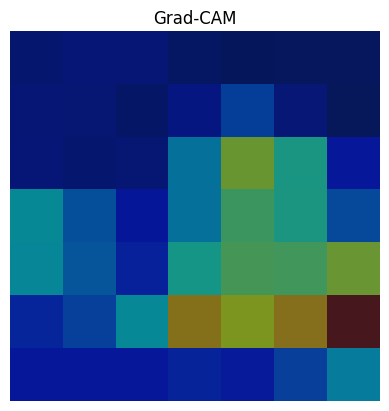

In [ ]:
gradcam = GradCAM(model)

image, label = test_dataset[0]

input_image = image.unsqueeze(0).to(device)

cam = gradcam.generate(input_image, class_idx=label)

plt.imshow(image.permute(1,2,0))
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# recreate EfficientNet-B0
model = models.efficientnet_b0(pretrained=False)

# IMPORTANT: classifier must match saved model
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 2)   # MUST be 2
)

# load weights
model.load_state_dict(torch.load("efficientnet_cifake.pth", map_location=device))

model = model.to(device)
model.eval()

print("Model loaded successfully ✅")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully ✅


PHASE 2

In [ ]:
import torch.nn.functional as F

def get_high_confidence_fakes(model, loader, threshold=0.95):

    model.eval()
    selected_images = []
    selected_labels = []
    selected_confidences = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            outputs = model(images)

            probs = F.softmax(outputs, dim=1)

            fake_conf = probs[:,0]   # index 0 = FAKE

            for i in range(len(images)):
                if labels[i] == 0 and fake_conf[i] > threshold:
                    selected_images.append(images[i].cpu())
                    selected_labels.append(labels[i].cpu())
                    selected_confidences.append(fake_conf[i].item())

            if len(selected_images) >= 10:
                break

    return selected_images, selected_confidences

In [ ]:
high_conf_images, high_conf_scores = get_high_confidence_fakes(model, test_loader)
print(high_conf_scores[:5])

[1.0, 1.0, 1.0, 1.0, 1.0]


Attack 1 — Gaussian Blur

In [ ]:
import torchvision.transforms.functional as TF
from PIL import Image,ImageFilter
import numpy as np

def gaussian_blur_attack(image_tensor, kernel_size=5):

    image = TF.to_pil_image(image_tensor)

    blurred = image.filter(ImageFilter.GaussianBlur(radius=1.5))

    return TF.to_tensor(blurred)

In [ ]:
def evaluate_single_image(model, image_tensor):

    model.eval()

    input_img = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        probs = F.softmax(output, dim=1)

    return probs.cpu().numpy()[0]

In [ ]:
image = high_conf_images[0]

original_probs = evaluate_single_image(model, image)

blurred = gaussian_blur_attack(image)

blurred_probs = evaluate_single_image(model, blurred)

print("Original:", original_probs)
print("Blurred:", blurred_probs)

Original: [1.000000e+00 5.510559e-13]
Blurred: [0.5987008  0.40129915]


FGSM (Minimal Pixel Perturbation)

In [ ]:
def fgsm_attack(model, image, label, epsilon=0.02):

    image = image.unsqueeze(0).to(device)
    label = torch.tensor([label]).to(device)

    image.requires_grad = True

    output = model(image)

    loss = F.cross_entropy(output, label)

    model.zero_grad()
    loss.backward()

    data_grad = image.grad.data

    perturbed_image = image + epsilon * data_grad.sign()

    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image.squeeze().detach().cpu()

In [ ]:
image = high_conf_images[0]
label = 0  # FAKE

perturbed = fgsm_attack(model, image, label, epsilon=0.02)

perturbed_probs = evaluate_single_image(model, perturbed)

print("Original:", original_probs)
print("FGSM:", perturbed_probs)

Original: [1.000000e+00 5.510559e-13]
FGSM: [1.215659e-29 1.000000e+00]


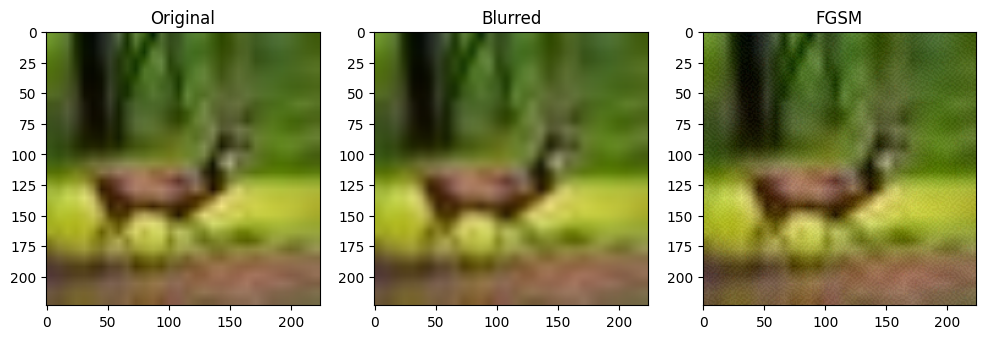

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(blurred.permute(1,2,0))
plt.title("Blurred")

plt.subplot(1,3,3)
plt.imshow(perturbed.permute(1,2,0))
plt.title("FGSM")

plt.show()

In [ ]:
def fgsm_attack(model, image, label, epsilon):

    image = image.unsqueeze(0).to(device)
    label = torch.tensor([label]).to(device)

    image.requires_grad = True

    output = model(image)

    loss = F.cross_entropy(output, label)

    model.zero_grad()
    loss.backward()

    grad = image.grad.data

    perturbed = image + epsilon * grad.sign()

    perturbed = torch.clamp(perturbed, 0, 1)

    return perturbed.squeeze().detach().cpu()

In [ ]:
def get_prediction_and_confidence(model, image):

    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image)

        probs = F.softmax(output, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        fake_conf = probs[0][0].item()
        real_conf = probs[0][1].item()

    return pred, fake_conf, real_conf

In [ ]:
def get_high_conf_fake_images(model, loader, threshold=0.99, max_images=20):

    images = []

    for batch_images, batch_labels in loader:

        for img, label in zip(batch_images, batch_labels):

            if label == 0:  # FAKE

                pred, fake_conf, real_conf = get_prediction_and_confidence(model, img)

                if pred == 0 and fake_conf > threshold:

                    images.append(img)

                    if len(images) >= max_images:
                        return images

    return images

In [ ]:
epsilons = [0, 0.005, 0.01, 0.015, 0.02, 0.03]

results = []

images = get_high_conf_fake_images(model, test_loader, max_images=20)

for idx, image in enumerate(tqdm(images)):

    original_pred, original_fake_conf, original_real_conf = get_prediction_and_confidence(model, image)

    evaded = False
    min_epsilon = None
    adv_fake_conf = None
    adv_real_conf = None

    for eps in epsilons:

        perturbed = fgsm_attack(model, image, label=0, epsilon=eps)

        pred, fake_conf, real_conf = get_prediction_and_confidence(model, perturbed)

        if pred == 1:  # flipped to REAL

            evaded = True
            min_epsilon = eps
            adv_fake_conf = fake_conf
            adv_real_conf = real_conf
            break

    results.append({
        "Image": idx,
        "Original Fake Confidence": round(original_fake_conf,4),
        "Original Real Confidence": round(original_real_conf,4),
        "Evaded": evaded,
        "Min Epsilon": min_epsilon if evaded else "Not evaded",
        "Adv Fake Confidence": round(adv_fake_conf,4) if evaded else None,
        "Adv Real Confidence": round(adv_real_conf,4) if evaded else None
    })

100%|██████████| 20/20 [00:02<00:00,  7.28it/s]


In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from tqdm import tqdm
df = pd.DataFrame(results)

df

,Image,Original Fake Confidence,Original Real Confidence,Evaded,Min Epsilon,Adv Fake Confidence,Adv Real Confidence
0,0,1.0000,0.0000,True,0.005,0.0031,0.9969
1,1,1.0000,0.0000,True,0.005,0.1001,0.8999
2,2,1.0000,0.0000,True,0.02,0.0000,1.0000
3,3,1.0000,0.0000,True,0.005,0.3761,0.6239
4,4,1.0000,0.0000,True,0.01,0.0000,1.0000
5,5,1.0000,0.0000,True,0.005,0.0882,0.9118
6,6,1.0000,0.0000,True,0.03,0.0000,1.0000
7,7,1.0000,0.0000,True,0.03,0.0000,1.0000
8,8,1.0000,0.0000,True,0.005,0.3438,0.6562
9,9,1.0000,0.0000,False,Not evaded,NaN,NaN


In [ ]:
success_rate = df["Evaded"].mean() * 100

print(f"Attack Success Rate: {success_rate:.2f}%")

Attack Success Rate: 95.00%


PHASE 3

In [ ]:
def adversarial_train(model, train_loader, optimizer, criterion, device, epsilon=0.01):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial images
        images.requires_grad = True

        outputs = model(images)

        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        grad = images.grad.data

        adv_images = images + epsilon * grad.sign()
        adv_images = torch.clamp(adv_images, 0, 1)

        # Train on adversarial images
        optimizer.zero_grad()

        adv_outputs = model(adv_images)

        adv_loss = criterion(adv_outputs, labels)

        adv_loss.backward()

        optimizer.step()

        total_loss += adv_loss.item()

    return total_loss / len(train_loader)

In [ ]:
epochs = 5

for epoch in range(epochs):

    loss = adversarial_train(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        epsilon=0.01
    )

    print(f"Epoch {epoch+1}, Loss:   {loss}")

Epoch 1, Loss:   2.0932963279008865
Epoch 2, Loss:   2.1106452351252236
Epoch 3, Loss:   2.095507563829422
Epoch 4, Loss:   2.0635130977392198
Epoch 5, Loss:   2.0355538888692855


In [ ]:
epsilons = [0, 0.005, 0.01, 0.015, 0.02, 0.03]

results_adv = []

images = get_high_conf_fake_images(model, test_loader, max_images=20)

for idx, image in enumerate(images):

    original_pred, original_fake_conf, original_real_conf = \
        get_prediction_and_confidence(model, image)

    evaded = False

    for eps in epsilons:

        perturbed = fgsm_attack(model, image, label=0, epsilon=eps)

        pred, fake_conf, real_conf = \
            get_prediction_and_confidence(model, perturbed)

        if pred == 1:
            evaded = True
            break

    results_adv.append(evaded)

In [ ]:
success_rate_adv = sum(results_adv) / len(results_adv) * 100

print("Attack Success Rate AFTER adversarial training:",
      success_rate_adv, "%")

Attack Success Rate AFTER adversarial training: 80.0 %
